In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [26]:
df = pd.read_csv("data.csv")
df.head()

,CampaignID,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates,IsSuccessful
0,CID_00000,76159,73518.028955,15,1903,Film,September,Australia,GBP,11,Yes,41758,3,0
1,CID_00001,69394,60068.683288,49,469,Art,October,Australia,GBP,7,Yes,79112,48,0
2,CID_00002,18652,22958.153470,58,148,Film,February,USA,EUR,17,No,3942,9,1
3,CID_00003,19487,24229.048390,39,780,Film,October,Germany,AUD,10,No,22047,35,1
4,CID_00004,26734,17984.630311,68,1622,Games,September,Australia,AUD,12,Yes,72568,17,0


In [27]:
df.shape

(100000, 14)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CampaignID           100000 non-null  object 
 1   GoalAmount           100000 non-null  int64  
 2   RaisedAmount         100000 non-null  float64
 3   DurationDays         100000 non-null  int64  
 4   NumBackers           100000 non-null  int64  
 5   Category             100000 non-null  object 
 6   LaunchMonth          100000 non-null  object 
 7   Country              100000 non-null  object 
 8   Currency             100000 non-null  object 
 9   OwnerExperience      100000 non-null  int64  
 10  VideoIncluded        100000 non-null  object 
 11  SocialMediaPresence  100000 non-null  int64  
 12  NumUpdates           100000 non-null  int64  
 13  IsSuccessful         100000 non-null  int64  
dtypes: float64(1), int64(7), object(6)
memory usage: 10.7+ MB


In [29]:
df.describe(include="all")

,CampaignID,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates,IsSuccessful
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000,100000,100000,100000.000000,100000,100000.000000,100000.000000,100000.000000
unique,100000,NaN,NaN,NaN,NaN,5,12,5,5,NaN,2,NaN,NaN,NaN
top,CID_00000,NaN,NaN,NaN,NaN,Art,December,Germany,GBP,NaN,No,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,20145,8487,20201,20196,NaN,50182,NaN,NaN,NaN
mean,NaN,50538.001310,50598.121803,52.047370,1003.347340,NaN,NaN,NaN,NaN,9.489130,NaN,50077.301010,24.483230,0.500940
std,NaN,28613.822592,33255.277493,21.653238,574.485153,NaN,NaN,NaN,NaN,5.763538,NaN,28767.521522,14.413833,0.500002
min,NaN,1000.000000,528.632349,15.000000,10.000000,NaN,NaN,NaN,NaN,0.000000,NaN,100.000000,0.000000,0.000000
25%,NaN,25724.750000,23396.500017,33.000000,505.000000,NaN,NaN,NaN,NaN,4.000000,NaN,25276.750000,12.000000,0.000000
50%,NaN,50706.000000,45980.674476,52.000000,1003.000000,NaN,NaN,NaN,NaN,9.000000,NaN,50024.500000,25.000000,1.000000
75%,NaN,75316.000000,72790.183158,71.000000,1502.000000,NaN,NaN,NaN,NaN,14.000000,NaN,74934.250000,37.000000,1.000000


In [30]:
df.isnull().sum()

CampaignID             0
GoalAmount             0
RaisedAmount           0
DurationDays           0
NumBackers             0
Category               0
LaunchMonth            0
Country                0
Currency               0
OwnerExperience        0
VideoIncluded          0
SocialMediaPresence    0
NumUpdates             0
IsSuccessful           0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
print("Target Distribution:")
print(df["IsSuccessful"].value_counts())

print("\nTarget Percentage:")
print(
    df["IsSuccessful"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target Distribution:
IsSuccessful
1    50094
0    49906
Name: count, dtype: int64

Target Percentage:
IsSuccessful
1    50.09
0    49.91
Name: proportion, dtype: float64


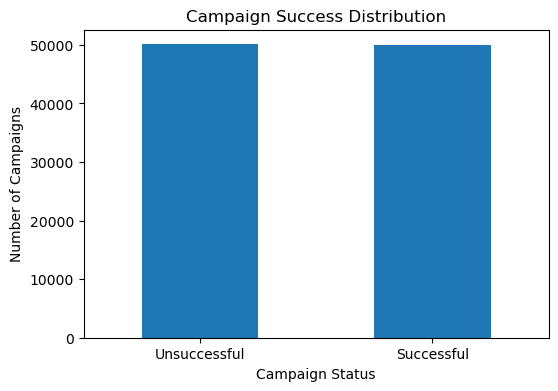

In [33]:
df["IsSuccessful"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Campaign Success Distribution")
plt.xlabel("Campaign Status")
plt.ylabel("Number of Campaigns")
plt.xticks(
    [0, 1],
    ["Unsuccessful", "Successful"],
    rotation=0
)
plt.show()

In [34]:
X = df.drop(columns=["CampaignID", "IsSuccessful"])
y = df["IsSuccessful"]

In [35]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['GoalAmount', 'RaisedAmount', 'DurationDays', 'NumBackers', 'Category', 'LaunchMonth', 'Country', 'Currency', 'OwnerExperience', 'VideoIncluded', 'SocialMediaPresence', 'NumUpdates']

Target:
IsSuccessful


In [36]:
num = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(num)

print("\nCategorical Features:")
print(cat)

Numerical Features:
['GoalAmount', 'RaisedAmount', 'DurationDays', 'NumBackers', 'OwnerExperience', 'SocialMediaPresence', 'NumUpdates']

Categorical Features:
['Category', 'LaunchMonth', 'Country', 'Currency', 'VideoIncluded']


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (80000, 12)
Testing Features: (20000, 12)
Training Target: (80000,)
Testing Target: (20000,)


In [38]:
prep = ColumnTransformer(
    transformers=[
        (
            "numerical", StandardScaler(),num
        ),
        (
            "categorical",OneHotEncoder(handle_unknown="ignore",sparse_output=False),cat
        )
    ]
)

In [39]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "SVM": LinearSVC(
        random_state=42,
        max_iter=5000
    )
}

In [40]:
pipelines = {}
for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", prep),
            ("model", model)
        ]
    )

In [41]:
for name, pipeline in pipelines.items():
    pipeline.fit(
        X_train,
        y_train
    )

    print(f"{name} trained successfully")

Random Forest trained successfully
KNN trained successfully
Decision Tree trained successfully
Naive Bayes trained successfully
SVM trained successfully


In [42]:
res = []

for name, model in pipelines.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    precision = precision_score(
        y_test,
        test_pred
    )

    recall = recall_score(
        y_test,
        test_pred
    )

    f1 = f1_score(
        y_test,
        test_pred
    )

    res.append({
        "Model": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

res_df = pd.DataFrame(res)
res_df = res_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

res_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,SVM,0.998825,0.99870,0.999201,0.998203,0.998702
1,Decision Tree,1.000000,0.99220,0.992510,0.991915,0.992212
2,Random Forest,1.000000,0.93255,0.971606,0.891406,0.929780
3,KNN,0.813775,0.68305,0.688795,0.670027,0.679282
4,Naive Bayes,0.663600,0.66825,0.739932,0.520810,0.611329


In [43]:
for name, model in pipelines.items():
    print(name)
    test_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=[
                "Unsuccessful",
                "Successful"
            ]
        )
    )

Random Forest
              precision    recall  f1-score   support

Unsuccessful       0.90      0.97      0.94      9981
  Successful       0.97      0.89      0.93     10019

    accuracy                           0.93     20000
   macro avg       0.94      0.93      0.93     20000
weighted avg       0.94      0.93      0.93     20000

KNN
              precision    recall  f1-score   support

Unsuccessful       0.68      0.70      0.69      9981
  Successful       0.69      0.67      0.68     10019

    accuracy                           0.68     20000
   macro avg       0.68      0.68      0.68     20000
weighted avg       0.68      0.68      0.68     20000

Decision Tree
              precision    recall  f1-score   support

Unsuccessful       0.99      0.99      0.99      9981
  Successful       0.99      0.99      0.99     10019

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.9

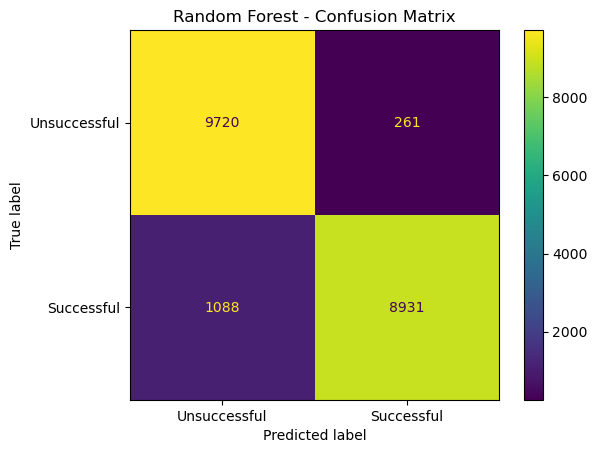

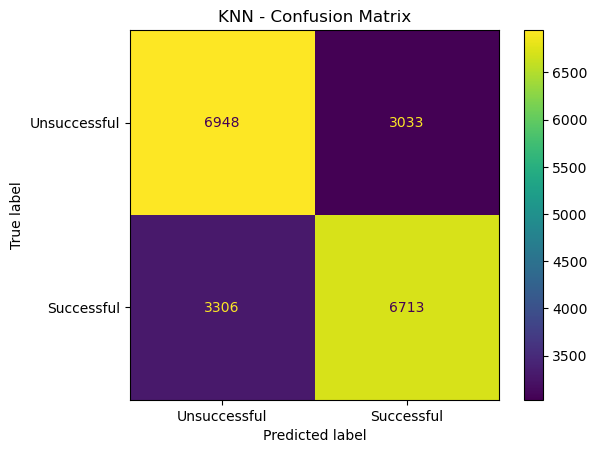

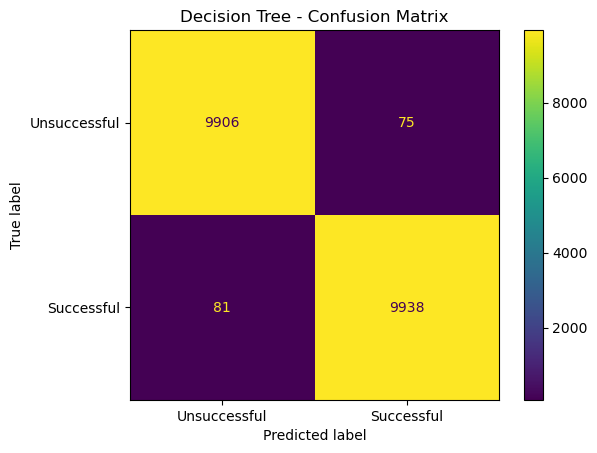

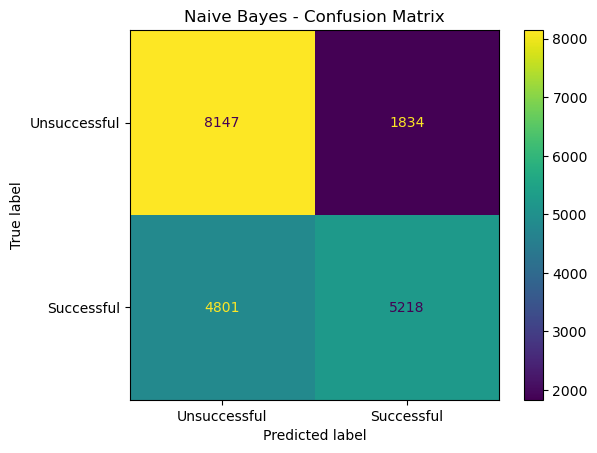

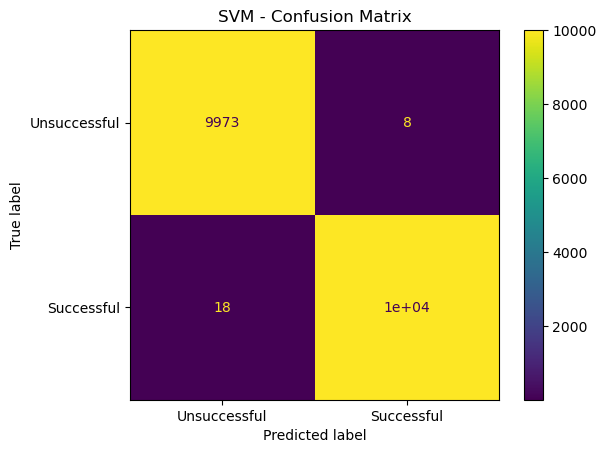

In [44]:
for name, model in pipelines.items():
    test_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        test_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Unsuccessful",
            "Successful"
        ]
    )
    disp.plot()

    plt.title(
        f"{name} - Confusion Matrix"
    )

    plt.show()

In [45]:
cv_results = []
for name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV F1-Score": scores.mean(),
        "CV Standard Deviation": scores.std()
    })

In [46]:
cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values(
    by="Mean CV F1-Score",
    ascending=False
).reset_index(drop=True)

cv_df

,Model,Mean CV F1-Score,CV Standard Deviation
0,SVM,0.998502,0.000197
1,Decision Tree,0.991366,0.000343
2,Random Forest,0.932488,0.002290
3,KNN,0.675649,0.001747
4,Naive Bayes,0.607450,0.003534


In [47]:
rf_params = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

dt_params = {
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

nb_params = {
    "model__var_smoothing": np.logspace(
        -10,
        -7,
        10
    )
}

svm_params = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

In [48]:
grids = {
    "Random Forest": rf_params,
    "Decision Tree": dt_params,
    "KNN": knn_params,
    "Naive Bayes": nb_params,
    "SVM": svm_params
}

tuned = {}
tres = []

for name in pipelines:
    search = RandomizedSearchCV(
        estimator=pipelines[name],
        param_distributions=grids[name],
        n_iter=5,
        cv=3,
        scoring="f1",
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    tuned[name] = search.best_estimator_

    tres.append({
        "Model": name,
        "Best CV F1-Score": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print(f"{name} tuning completed.")

Random Forest tuning completed.
KNN tuning completed.
Decision Tree tuning completed.
Naive Bayes tuning completed.
SVM tuning completed.


In [49]:
tuning_df = pd.DataFrame(tres)
tuning_df

,Model,Best CV F1-Score,Best Parameters
0,Random Forest,0.932862,"{'model__n_estimators': 150, 'model__min_sampl..."
1,KNN,0.709054,"{'model__weights': 'uniform', 'model__n_neighb..."
2,Decision Tree,0.990326,"{'model__min_samples_split': 5, 'model__min_sa..."
3,Naive Bayes,0.607014,{'model__var_smoothing': 4.641588833612773e-08}
4,SVM,0.999401,{'model__C': 100}


In [50]:
tresults = []
for name, model in tuned.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    tresults.append({
        "Model": name,
        "Train Accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "Test Accuracy": accuracy_score(
            y_test,
            test_pred
        ),
        "Precision": precision_score(
            y_test,
            test_pred
        ),
        "Recall": recall_score(
            y_test,
            test_pred
        ),
        "F1-Score": f1_score(
            y_test,
            test_pred
        )
    })

tuned_res = pd.DataFrame(tresults)
tuned_res = tuned_res.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

tuned_res

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,SVM,0.999625,0.99960,0.999800,0.999401,0.999601
1,Decision Tree,0.999012,0.99285,0.994393,0.991316,0.992853
2,Random Forest,1.000000,0.93770,0.978405,0.895399,0.935064
3,KNN,0.792175,0.71595,0.733427,0.680208,0.705815
4,Naive Bayes,0.663600,0.66825,0.739932,0.520810,0.611329


In [ ]:
best_name = tuned_res.loc[0, "Model"]
best = tuned[best_name]

print("Best Model:", best_name)

print(
    "\nBest Model F1-Score:",
    round(
        tuned_res.loc[0, "F1-Score"],
        4
    )
)

Best Model: SVM

Best Model F1-Score: 0.9996


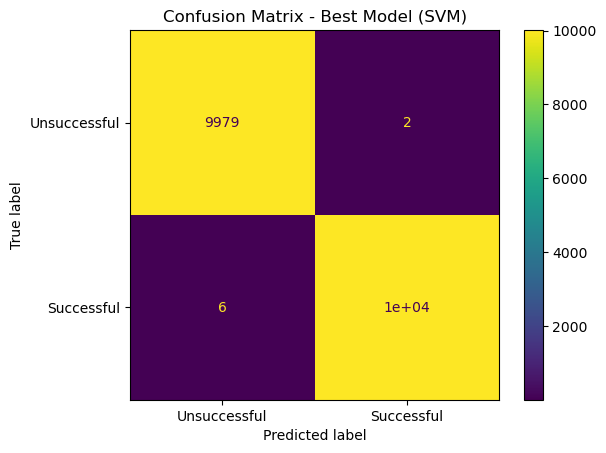

In [52]:
best_pred = best.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
)

disp.plot()

plt.title(
    f"Confusion Matrix - Best Model ({best_name})"
)

plt.show()

In [53]:
print(
    classification_report(
        y_test,
        best_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ]
    )
)

              precision    recall  f1-score   support

Unsuccessful       1.00      1.00      1.00      9981
  Successful       1.00      1.00      1.00     10019

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



## Model Comparison and Insights

The five classification models—Random Forest, KNN, Decision Tree, Naive Bayes, and Support Vector Machine—were evaluated using Accuracy, Precision, Recall, and F1-Score. Cross-validation was also performed to assess model stability, followed by hyperparameter tuning using GridSearchCV.

### Random Forest

**Strengths:**

* Handles numerical and categorical features effectively after preprocessing.
* Can capture complex relationships between features.
* Generally provides good predictive performance.

**Weaknesses:**

* Can require more computational resources than simpler models.
* The resulting model is less interpretable than a single Decision Tree.

### KNN

**Strengths:**

* Simple and easy to understand.
* Scaling makes it suitable for distance-based classification.
* Does not require a complex training process.

**Weaknesses:**

* Prediction can be slower for larger datasets.
* Performance depends strongly on the choice of `k` and distance metric.

### Decision Tree

**Strengths:**

* Easy to interpret and visualize.
* Can capture non-linear relationships.
* Requires relatively little preprocessing.

**Weaknesses:**

* Can overfit the training data.
* Performance can change significantly depending on tree parameters.

### Naive Bayes

**Strengths:**

* Simple and computationally efficient.
* Works well as a baseline classification algorithm.
* Requires relatively little training time.

**Weaknesses:**

* Assumes independence between features.
* Its performance may decrease when features are strongly related.

### Support Vector Machine

**Strengths:**

* Effective for classification problems.
* Works well with scaled numerical features.
* Can model complex decision boundaries when appropriate kernels are used.

**Weaknesses:**

* Can require more computation for larger datasets.
* Performance depends on appropriate parameter selection.

### Best Model

Based on the final evaluation results, **SUPPORT VECTOR MACHINE** achieved the highest overall **F1-Score** and was therefore selected as the best-performing model for this classification problem.

The selected model provides the best balance between Precision and Recall among the evaluated models.

### Possible Improvements

The model performance could potentially be improved through further hyperparameter tuning, additional feature selection, and testing the models on a larger and more representative dataset.
